# Titanic dataset **EDA**

In [ ]:
#  1. Load Titanic dataset, inspect missingness and dtypes.
import pandas as pd

# Google Sheet CSV export link
url = "https://docs.google.com/spreadsheets/d/1V0cuE49BOew2Cjw1jmQVK9kdwGaFcud1J1d6v5CkLyg/export?format=csv"

df = pd.read_csv(url)

# First 5 rows
df.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


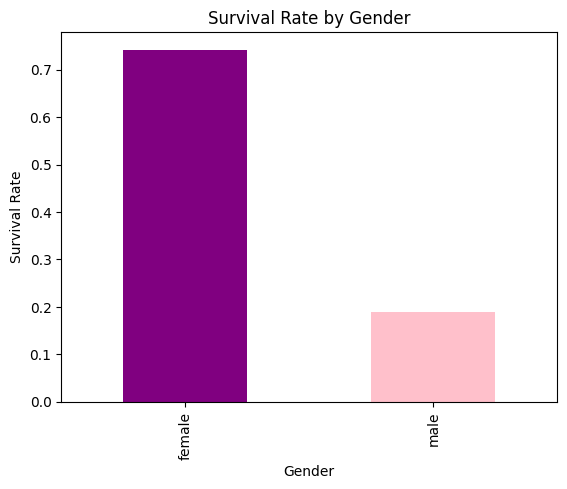

In [ ]:
# 2. Analyze survival rates by sex, class, age buckets.
#Survival by Gender
survival_sex = df.groupby("Sex")["Survived"].mean()

plt.figure()
survival_sex.plot(kind="bar", color=["purple","pink"])
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

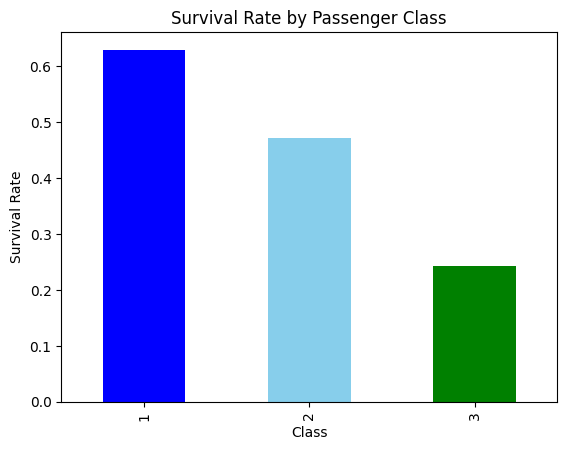

In [ ]:
# Survival by Passenger Class
survival_class = df.groupby("Pclass")["Survived"].mean()

plt.figure()
survival_class.plot(kind="bar", color=["blue","skyblue","green"])
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Class")
plt.ylabel("Survival Rate")
plt.show()

/tmp/ipykernel_695/3885326368.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby("Age Group")["Survived"].mean()


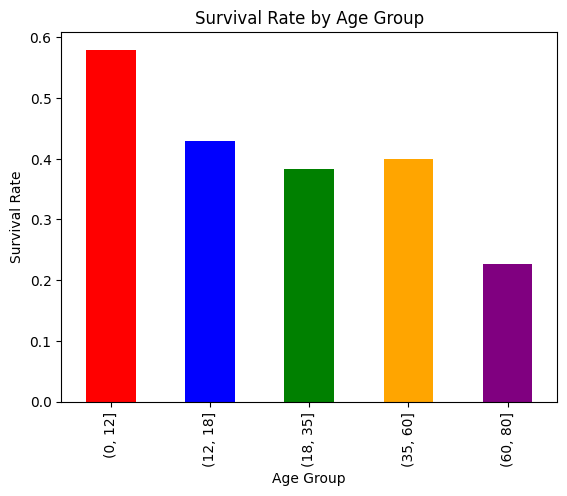

In [ ]:
# Survival by Age Buckets
# Create age groups
df["Age Group"] = pd.cut(df["Age"], bins=[0,12,18,35,60,80])

age_survival = df.groupby("Age Group")["Survived"].mean()

plt.figure()
age_survival.plot(kind="bar", color=["red","blue","green","orange","purple"])
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.show()

/tmp/ipykernel_695/4236025232.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Survived", y="Age", data=df, palette=["skyblue","orange"])


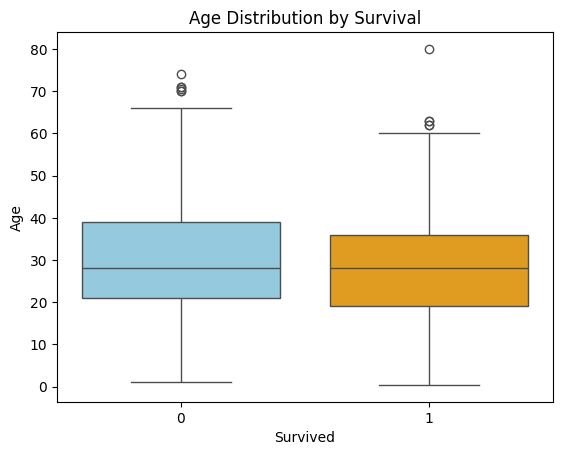

In [ ]:
# 3. Age Distribution by Survival

plt.figure()
sns.boxplot(x="Survived", y="Age", data=df, palette=["skyblue","orange"])
plt.title("Age Distribution by Survival")
plt.show()

/tmp/ipykernel_695/528049277.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Survived", y="Fare", data=df, palette=["red","orange"])


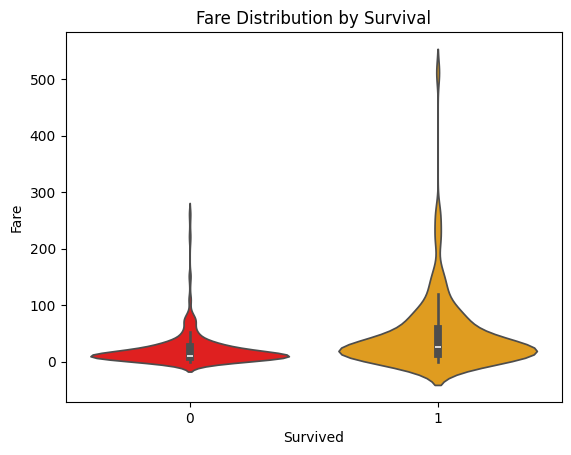

In [ ]:
# Fare Distribution by Survival
plt.figure()
sns.violinplot(x="Survived", y="Fare", data=df, palette=["red","orange"])
plt.title("Fare Distribution by Survival")
plt.show()

**Short Insight Report (3–5 Points)**


Key Insights from Titanic EDA

Gender had the strongest impact on survival — females had much higher survival rates than males due to the “women and children first” evacuation rule.

Passenger class significantly influenced survival — first-class passengers survived more often than third-class passengers.

Children generally had better survival chances compared to older adults.

Higher ticket fares often correlate with survival, indicating wealthier passengers had better access to lifeboats.

Missing data exists in Age, Cabin, and Embarked, which must be handled during preprocessing before building models.